In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval (x) if pd.notna(x) else x)


In [72]:
df_da_ind = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()
df_da_ind = df_da_ind.dropna(subset=['salary_year_avg'])


In [ ]:
df_da_ind = df_da_ind.explode('job_skills')
df_da_ind[['salary_year_avg', 'job_skills']]

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel
...,...,...
777313,111202.0,looker
777313,111202.0,powerpoint
784033,111175.0,power bi
784033,111175.0,tableau


In [74]:
df_da_ind_grp = df_da_ind.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by= 'median', ascending=False)
df_da_top_pay = df_da_ind_grp.sort_values(by='median', ascending=False).head(10)
df_da_skills = df_da_ind_grp.sort_values(by='count', ascending=False).head(10)
df_da_skills

,count,median
job_skills,,
sql,46,96050.0
excel,39,98500.0
python,36,96050.0
tableau,20,108087.5
r,18,79200.0
power bi,17,111175.0
azure,15,93600.0
aws,12,79200.0
oracle,11,79200.0


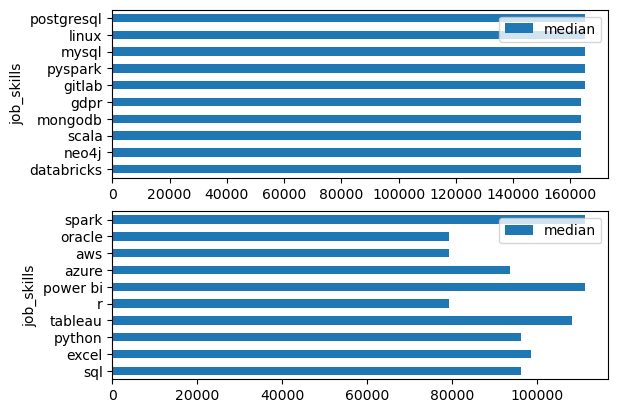

In [75]:
fig, ax = plt.subplots(2, 1 )
df_da_top_pay.plot(kind='barh', y='median', ax=ax[0])
ax[0].invert_yaxis()
plt.xlim()

df_da_skills[::-1].plot(kind='barh', y='median',ax=ax[1])
ax[1].invert_yaxis()


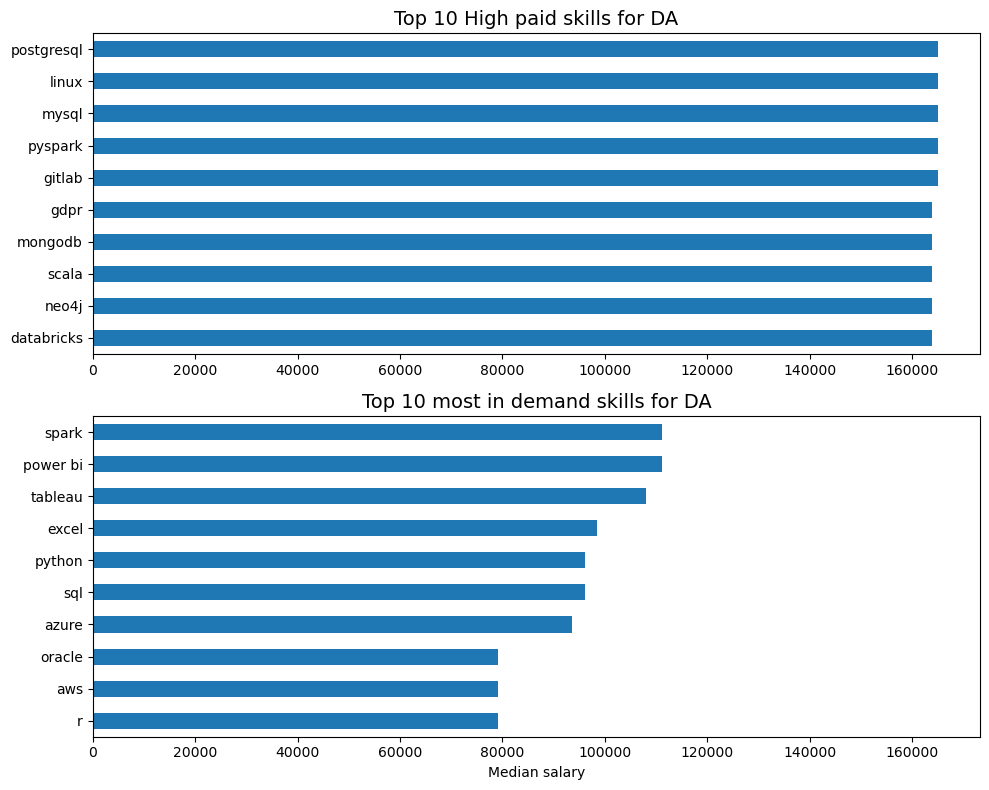

In [76]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Top-paying skills
df_da_top_pay.plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 High paid skills for DA', fontsize=14)
ax[0].set_ylabel('')

# Skills in ascending order of median salary
df_da_skills.sort_values(by='median', ascending=True).plot(
    kind='barh',
    y='median',
    ax=ax[1],
    legend=False
)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 most in demand skills for DA', fontsize=14)
ax[1].set_ylabel('')
ax[1].set_xlabel('Median salary')

plt.tight_layout()

plt.show()